# ViT Invariance — All Models Combined

Two figures comparing DINOv1, DINOv3, and Supervised ViT (12 blocks each):

| | Pooled features | Raw (flattened) features |
|---|---|---|
| **Per-block** | Figure 1 left | Figure 1 right |

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

outdir = 'outputs'

# ── Pooled features ───────────────────────────────────────────────────────────
dinov1_pooled = np.load(os.path.join(outdir, 'dinov1_vit_inv_pooled.npy'), allow_pickle=True).item()
dinov3_pooled = np.load(os.path.join(outdir, 'dinov3_vit_inv_pooled.npy'), allow_pickle=True).item()
sup_pooled    = np.load(os.path.join(outdir, 'sup_vit_inv_pooled.npy'),    allow_pickle=True).item()

# ── Raw (flattened) features ──────────────────────────────────────────────────
dinov1_raw = np.load(os.path.join(outdir, 'dinov1_vit_inv_raw.npy'), allow_pickle=True).item()
dinov3_raw = np.load(os.path.join(outdir, 'dinov3_vit_inv_raw.npy'), allow_pickle=True).item()
sup_raw    = np.load(os.path.join(outdir, 'sup_vit_inv_raw.npy'),    allow_pickle=True).item()

print('Pooled layers:', len(dinov1_pooled['layer_names']), len(dinov3_pooled['layer_names']), len(sup_pooled['layer_names']))
print('Raw    layers:', len(dinov1_raw['layer_names']),    len(dinov3_raw['layer_names']),    len(sup_raw['layer_names']))

Pooled layers: 12 12 12
Raw    layers: 12 12 12


In [2]:
MODELS = [
    {'color': '#2aa876', 'label': 'DINOv1'},
    {'color': '#3a7abf', 'label': 'DINOv3'},
    {'color': '#7b52b9', 'label': 'Supervised'},
]

def plot_vit(ax, datasets, title):
    for m, d in zip(MODELS, datasets):
        values = d['values']
        mean   = values.mean(axis=1)
        sem    = values.std(axis=1) / np.sqrt(values.shape[1])
        x      = np.arange(len(mean))
        ax.plot(x, mean, 'o-', color=m['color'], lw=2, ms=6, label=m['label'])
        ax.fill_between(x, mean - sem, mean + sem, alpha=0.15, color=m['color'])
    ax.axhline(0, color='gray', lw=1, linestyle='--')
    ax.set_ylim(-0.1, 0.7)
    ax.set_xticks(np.arange(len(datasets[0]['layer_names'])))
    ax.set_xticklabels(datasets[0]['layer_names'], fontsize=9)
    ax.set_xlabel('Block')
    ax.set_ylabel('Invariance')
    ax.set_title(title, fontsize=12)
    ax.legend(frameon=False, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## Figure — Pooled vs Raw

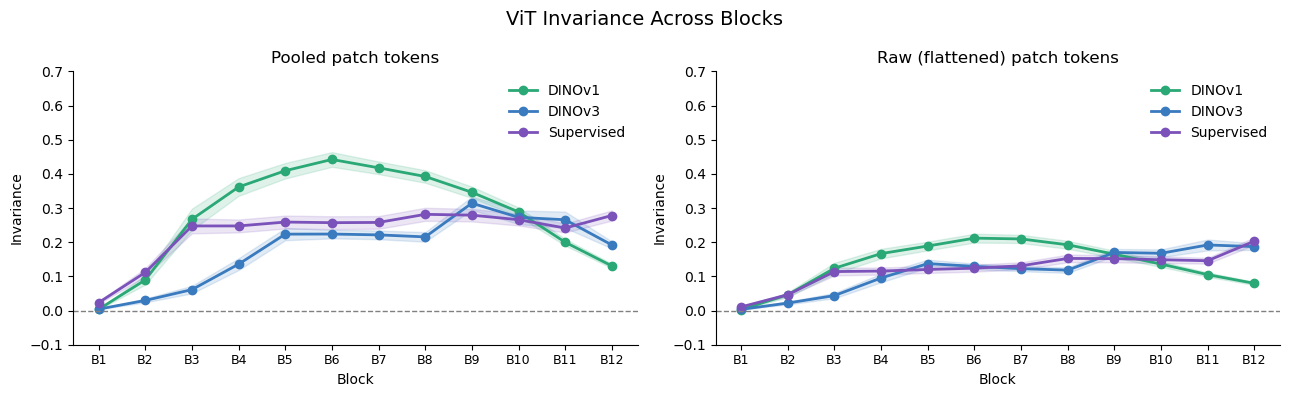

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_vit(axes[0], [dinov1_pooled, dinov3_pooled, sup_pooled],
         'Pooled patch tokens')
plot_vit(axes[1], [dinov1_raw, dinov3_raw, sup_raw],
         'Raw (flattened) patch tokens')

plt.suptitle('ViT Invariance Across Blocks', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/vit_invariance_combined.png', dpi=300, bbox_inches='tight')
plt.show()